In [11]:
import pymc as pm
import numpy as np
import matplotlib.pyplot as plt
import arviz as az
from scipy.stats import beta, norm

plt.style.use('seaborn-v0_8-colorblind')
plt.rcParams['lines.linewidth'] = 2.5
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.rcParams['legend.fontsize'] = 12
plt.rcParams['axes.edgecolor'] = 'black'
plt.rcParams['axes.linewidth'] = 1.2

In [2]:
# --- Data: 3 out of 5 prefer tea ---
n = 5
y = 3

# --- Analytic posterior ---
alpha_prior, beta_prior = 1, 1  # Beta(2,2) prior for tea preference
alpha_post = alpha_prior + y
beta_post = beta_prior + (n - y)

# grid for plotting
theta_vals = np.linspace(0, 1, 200)
posterior_pdf = beta.pdf(theta_vals, alpha_post, beta_post)

In [3]:
# --- VI approximation using PyMC ---
with pm.Model() as model:
    p = pm.Beta("p", alpha_prior, beta_prior)
    obs = pm.Binomial("obs", n=n, p=p, observed=y)
    
    approx = pm.fit(method="advi", n=20000)  # ADVI
    trace_vi = approx.sample(1000)

/Users/quannguyen/anaconda3/envs/gb/lib/python3.10/site-packages/rich/live.py:256: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Finished [100%]: Average Loss = 1.8022


In [10]:
(
    approx.mean.eval(),
    approx.std.eval(),
    mu_vi,
    sigma_vi,
)

(array([0.31092458]),
 array([0.8811738]),
 np.float64(0.5645407546116902),
 np.float64(0.18681296040303522))

In [12]:
# Extract VI samples of p
p_samples = trace_vi.posterior["p"].values.flatten()

# Fit Normal approximation to VI samples
mu_vi = np.mean(p_samples)
sigma_vi = np.std(p_samples)
normal_pdf = norm.pdf(theta_vals, mu_vi, sigma_vi)

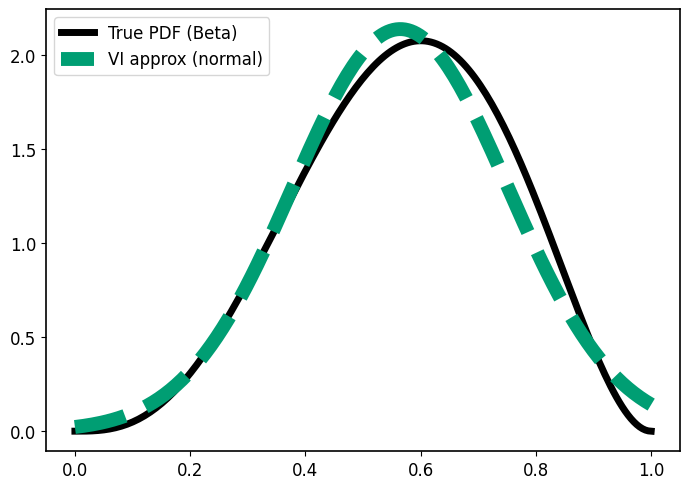

In [18]:
# --- Plot ---
plt.figure(figsize=(7,5))
plt.plot(theta_vals, posterior_pdf, label="True PDF (Beta)", color="k", lw=5)
plt.plot(theta_vals, normal_pdf, label="VI approx (normal)", color="C1", lw=10, linestyle="--")

# # Overlay samples from VI for illustration
# plt.scatter(p_samples, np.zeros_like(p_samples) - 0.2, 
#             color="C1", alpha=0.3, s=10, label="VI samples")

# plt.xlabel("Tea preference probability θ")
# plt.ylabel("Density")
# plt.title("VI Normal Approximation vs True Posterior")
plt.legend()
# plt.ylim(bottom=-0.3)
plt.tight_layout()
plt.show()